# Assignment - Part 4: Data Visualization & Machine Learning
# Theme: Student Performance Analysis & Prediction

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score




In [3]:
!pip install scikit-learn pandas matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df = pd.read_csv("students.csv")

# TASK 1 - Data Exploration with Pandas 

In [5]:
print("=" * 60)
print("TASK 1 - DATA EXPLORATION WITH PANDAS")
print("=" * 60)

TASK 1 - DATA EXPLORATION WITH PANDAS


In [6]:
print("\n--- 1. First 5 Rows ---")
print(df.head())


--- 1. First 5 Rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [7]:
print("\n--- 2. Shape and Data Types ---")
print("Shape (rows x columns):", df.shape)
print("\nData Types:")
print(df.dtypes)



--- 2. Shape and Data Types ---
Shape (rows x columns): (15, 9)

Data Types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [8]:
print("\n--- 3. Summary Statistics ---")
print(df.describe())


--- 3. Summary Statistics ---
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%     

In [9]:
print("\n--- 4. Pass/Fail Count ---")
pass_fail_counts = df['passed'].value_counts()
pass_fail_counts.index = ['Passed' if i == 1 else 'Failed' for i in pass_fail_counts.index]
print(pass_fail_counts)


--- 4. Pass/Fail Count ---
Passed    9
Failed    6
Name: count, dtype: int64


In [10]:
print("\n--- 5. Average Score Per Subject (Pass vs Fail) ---")
subject_cols = ['math', 'science', 'english', 'history', 'pe']

avg_pass = df[df['passed'] == 1][subject_cols].mean()
avg_fail = df[df['passed'] == 0][subject_cols].mean()

print("\nPassing Students - Average Scores:")
print(avg_pass.round(2))
print("\nFailing Students - Average Scores:")
print(avg_fail.round(2))



--- 5. Average Score Per Subject (Pass vs Fail) ---

Passing Students - Average Scores:
math       78.22
science    78.56
english    79.11
history    73.44
pe         86.00
dtype: float64

Failing Students - Average Scores:
math       45.17
science    49.00
english    46.83
history    48.33
pe         58.00
dtype: float64


In [11]:
print("\n--- 6. Student with Highest Overall Average ---")
df['avg_score'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['avg_score'].idxmax()]
print(f"Top Student: {top_student['name']} with an average score of {top_student['avg_score']:.2f}")



--- 6. Student with Highest Overall Average ---
Top Student: Diana with an average score of 94.00


# TASK 2 - Data Visualization with Matplotlib 

In [12]:
print("\n" + "=" * 60)
print("TASK 2 - DATA VISUALIZATION WITH MATPLOTLIB")
print("=" * 60)


TASK 2 - DATA VISUALIZATION WITH MATPLOTLIB


In [13]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# --- Plot 1: Bar Chart - Average score per subject ---

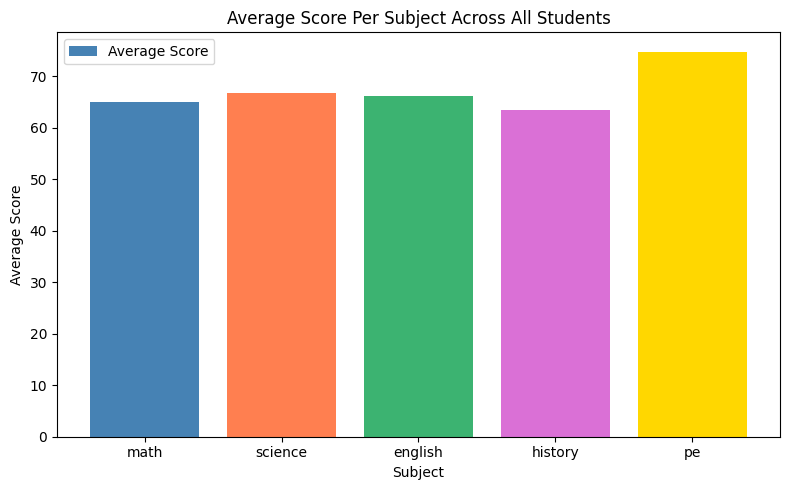

Plot 1 saved as plot1_bar.png


In [14]:
avg_per_subject = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_per_subject.index, avg_per_subject.values,
        color=['steelblue', 'coral', 'mediumseagreen', 'orchid', 'gold'])
plt.title("Average Score Per Subject Across All Students")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.legend(["Average Score"])
plt.tight_layout()
plt.savefig("plot1_bar.png")
plt.show()
print("Plot 1 saved as plot1_bar.png")

# --- Plot 2: Histogram - Distribution of Math scores ---

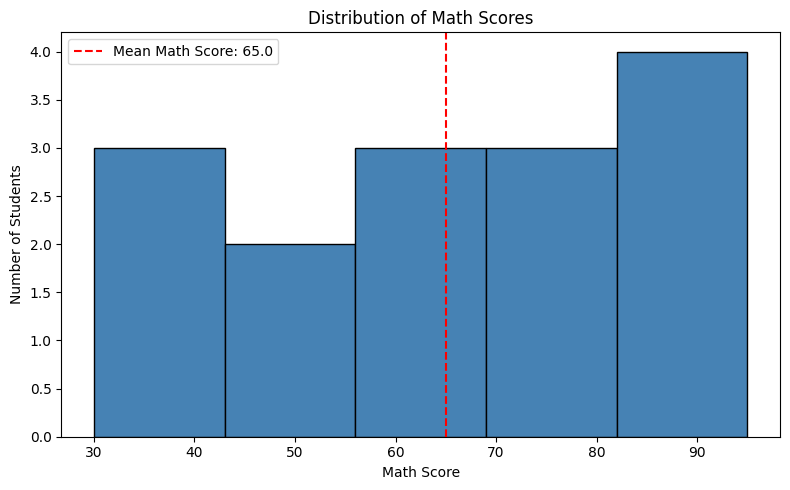

Plot 2 saved as plot2_histogram.png


In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='steelblue', edgecolor='black')
mean_math = df['math'].mean()
plt.axvline(mean_math, color='red', linestyle='--',
            label=f'Mean Math Score: {mean_math:.1f}')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_histogram.png")
plt.show()
print("Plot 2 saved as plot2_histogram.png")

# --- Plot 3: Scatter Plot - Study Hours vs Avg Score ---

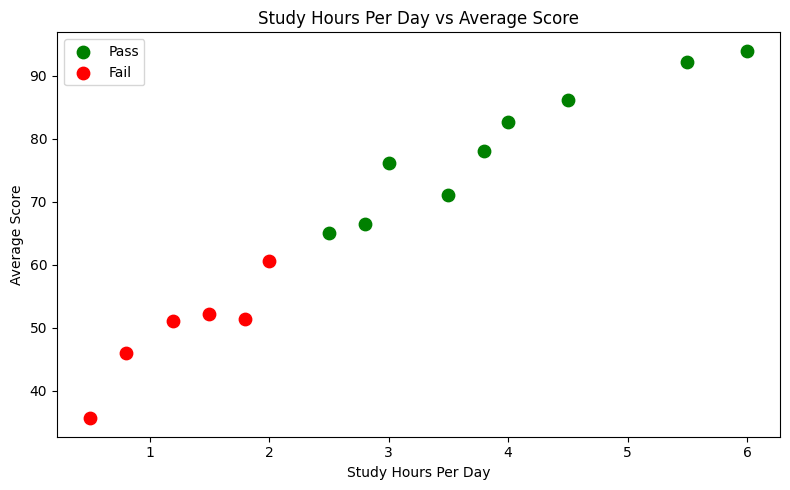

Plot 3 saved as plot3_scatter.png


In [16]:
plt.figure(figsize=(8, 5))
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'],
            color='green', label='Pass', s=80)
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'],
            color='red', label='Fail', s=80)
plt.title("Study Hours Per Day vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_scatter.png")
plt.show()
print("Plot 3 saved as plot3_scatter.png")

# --- Plot 4: Box Plot - Attendance for Pass vs Fail ---

C:\Users\USER\AppData\Local\Temp\ipykernel_32380\1262895190.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


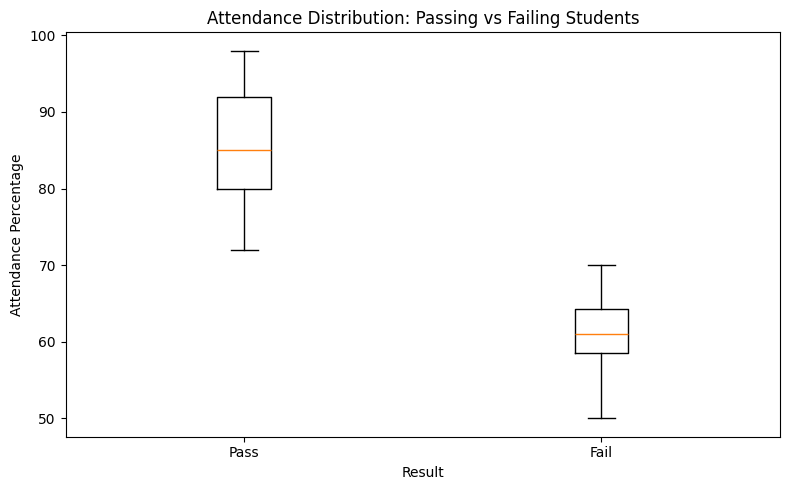

Plot 4 saved as plot4_boxplot.png


In [17]:
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution: Passing vs Failing Students")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")
plt.tight_layout()
plt.savefig("plot4_boxplot.png")
plt.show()
print("Plot 4 saved as plot4_boxplot.png")

# --- Plot 5: Line Plot - Math & Science scores per student ---

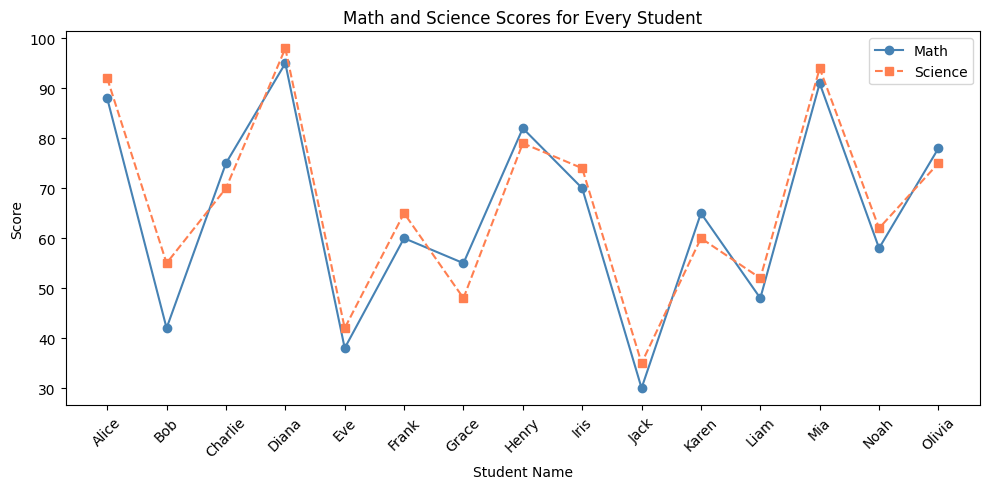

Plot 5 saved as plot5_line.png


In [18]:
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', linestyle='-',
         label='Math', color='steelblue')
plt.plot(df['name'], df['science'], marker='s', linestyle='--',
         label='Science', color='coral')
plt.title("Math and Science Scores for Every Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()
print("Plot 5 saved as plot5_line.png")

# TASK 3 - Data Visualization with Seaborn 

In [19]:
print("\n" + "=" * 60)
print("TASK 3 - DATA VISUALIZATION WITH SEABORN")
print("=" * 60)


TASK 3 - DATA VISUALIZATION WITH SEABORN


# --- Seaborn Plot 1: Bar plot - Avg Math & Science by passed ---

C:\Users\USER\AppData\Local\Temp\ipykernel_32380\799958061.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_32380\799958061.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Set1')


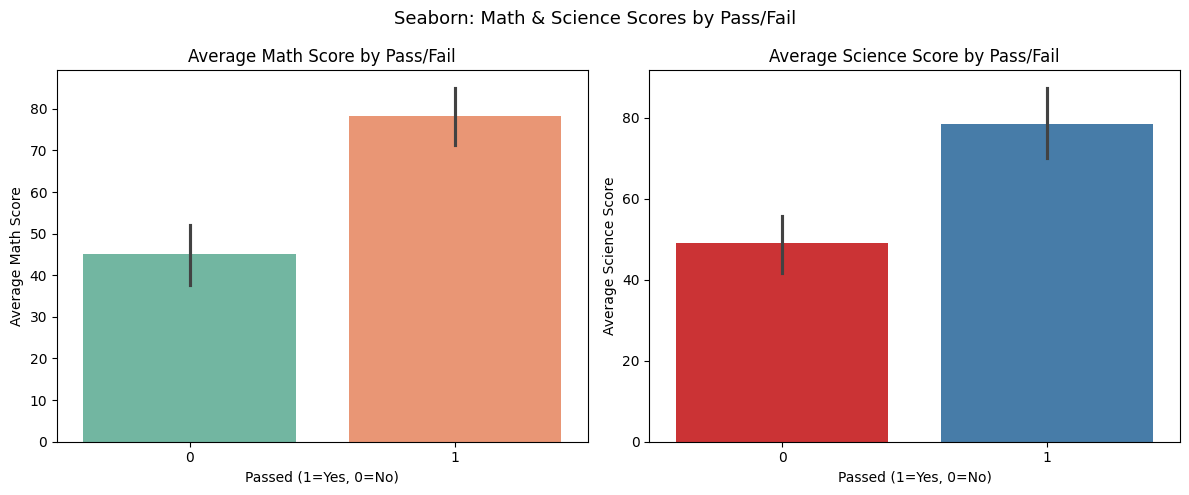

Seaborn Plot 1 saved as plot6_seaborn_bar.png


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='Set2')
ax1.set_title("Average Math Score by Pass/Fail")
ax1.set_xlabel("Passed (1=Yes, 0=No)")
ax1.set_ylabel("Average Math Score")

sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Set1')
ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Passed (1=Yes, 0=No)")
ax2.set_ylabel("Average Science Score")

plt.suptitle("Seaborn: Math & Science Scores by Pass/Fail", fontsize=13)
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()
print("Seaborn Plot 1 saved as plot6_seaborn_bar.png")


# --- Seaborn Plot 2: Scatter with regression lines ---

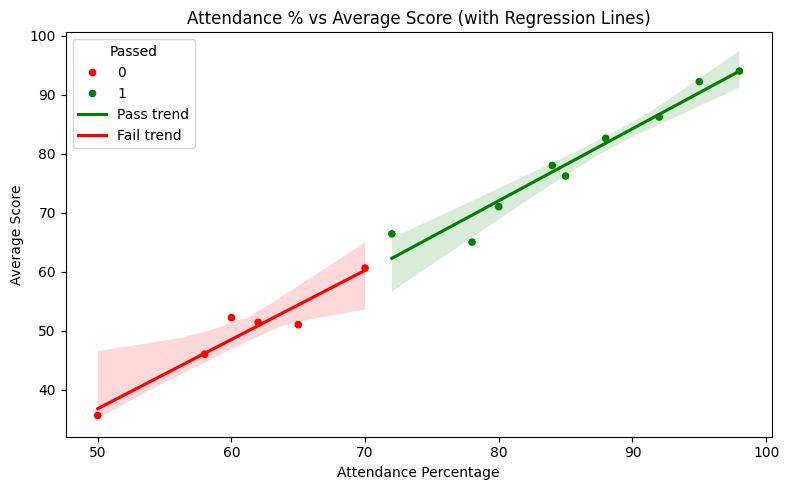

Seaborn Plot 2 saved as plot7_seaborn_scatter.png


In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='attendance_pct', y='avg_score',
                hue='passed', palette={1: 'green', 0: 'red'})
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            scatter=False, color='green', label='Pass trend')
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            scatter=False, color='red', label='Fail trend')
plt.title("Attendance % vs Average Score (with Regression Lines)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend(title="Passed")
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()
print("Seaborn Plot 2 saved as plot7_seaborn_scatter.png")

# --- Seaborn vs Matplotlib comparison comment ---
# Seaborn was easier and required fewer lines of code for grouped plots.
# Adding regression lines with sns.regplot() was very straightforward
# compared to manually calculating them in Matplotlib. However, Matplotlib
# gave more fine-grained control over layout and custom styling details.

# TASK 4 - Machine Learning with scikit-learn 

In [22]:
print("\n" + "=" * 60)
print("TASK 4 - MACHINE LEARNING WITH SCIKIT-LEARN")
print("=" * 60)


TASK 4 - MACHINE LEARNING WITH SCIKIT-LEARN


# --- Step 1: Prepare Data ---

In [19]:
import pandas as pd
df = pd.read_csv("students.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [20]:
feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

In [11]:
from sklearn.model_selection import train_test_split

# Split into train (80%) and test (20%)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features - fit on train only, transform both

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData split complete.")
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")


Data split complete.
Training samples: 12, Test samples: 3


# --- Step 2: Train a Model ---

In [23]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_accuracy = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"\nModel Training Accuracy: {train_accuracy * 100:.2f}%")



Model Training Accuracy: 100.00%


# --- Step 3: Evaluate the Model ---

In [24]:
y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Test Accuracy: {test_accuracy * 100:.2f}%")

print("\n--- Prediction Results for Each Test Student ---")
test_names = df.loc[X_test.index, 'name']
for name, actual, predicted in zip(test_names, y_test, y_pred):
    result = "✅ Correct" if actual == predicted else "❌ Wrong"
    actual_label = "Pass" if actual == 1 else "Fail"
    predicted_label = "Pass" if predicted == 1 else "Fail"
    print(f"  {name}: Actual={actual_label}, Predicted={predicted_label} → {result}")


Model Test Accuracy: 100.00%

--- Prediction Results for Each Test Student ---
  Jack: Actual=Fail, Predicted=Fail → ✅ Correct
  Liam: Actual=Fail, Predicted=Fail → ✅ Correct
  Alice: Actual=Pass, Predicted=Pass → ✅ Correct


# --- Step 4: Feature Importance ---

In [25]:
coefficients = model.coef_[0]
feature_importance = list(zip(feature_cols, coefficients))
feature_importance_sorted = sorted(feature_importance,
                                   key=lambda x: abs(x[1]), reverse=True)

print("\n--- Feature Coefficients (sorted by absolute value) ---")
for feat, coef in feature_importance_sorted:
    direction = "→ pushes towards Pass" if coef > 0 else "→ pushes towards Fail"
    print(f"  {feat}: {coef:.4f}  {direction}")


--- Feature Coefficients (sorted by absolute value) ---
  english: 0.8125  → pushes towards Pass
  attendance_pct: 0.5219  → pushes towards Pass
  study_hours_per_day: 0.4844  → pushes towards Pass
  pe: 0.4750  → pushes towards Pass
  math: 0.4379  → pushes towards Pass
  science: 0.3230  → pushes towards Pass
  history: 0.2629  → pushes towards Pass


# Horizontal bar chart for feature importance

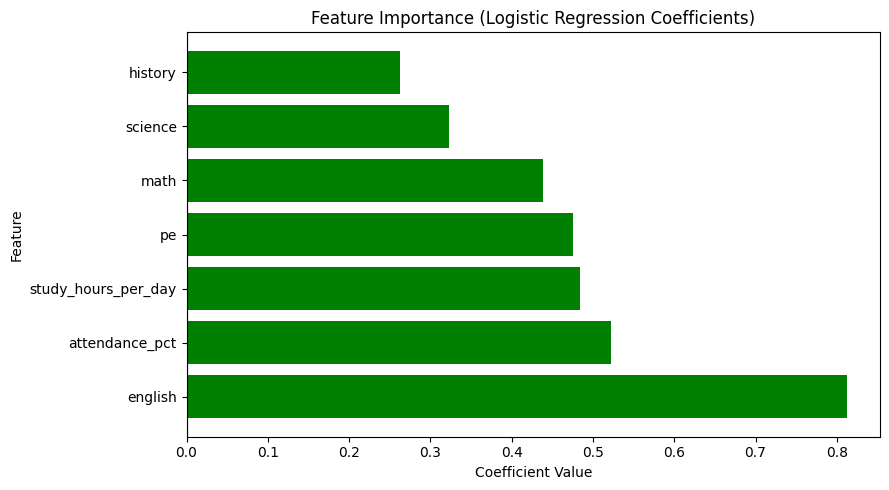


Feature importance chart saved as plot8_feature_importance.png


In [26]:
features = [f[0] for f in feature_importance_sorted]
coefs = [f[1] for f in feature_importance_sorted]
colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure(figsize=(9, 5))
plt.barh(features, coefs, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()
print("\nFeature importance chart saved as plot8_feature_importance.png")

# --- Step 5 : Predict for a New Student ---

In [27]:
print("\n" + "=" * 60)
print("STEP 5  - PREDICT FOR A NEW STUDENT")
print("=" * 60)


STEP 5  - PREDICT FOR A NEW STUDENT


# order must match feature columns

In [28]:
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)

result_label = "Pass ✅" if prediction[0] == 1 else "Fail ❌"
print(f"\nNew Student Data: Math=75, Science=70, English=68, History=65,")
print(f"                  PE=80, Attendance=82%, Study=3.2hrs/day")
print(f"Prediction       : {result_label}")
print(f"Probability Fail : {probability[0][0] * 100:.2f}%")
print(f"Probability Pass : {probability[0][1] * 100:.2f}%")

print("\n" + "=" * 60)
print("ALL TASKS COMPLETED SUCCESSFULLY!")
print("=" * 60)


New Student Data: Math=75, Science=70, English=68, History=65,
                  PE=80, Attendance=82%, Study=3.2hrs/day
Prediction       : Pass ✅
Probability Fail : 9.20%
Probability Pass : 90.80%

ALL TASKS COMPLETED SUCCESSFULLY!


C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
